# 🧠 GraphGuard — Notebook 2: Training

**Covers:**
- Phase 2: Baseline GraphSAGE (establishes "before" numbers)
- Phase 3: TempoStruct-GAN — Generator + Edge Predictor + Dual-Head Discriminator
- Phase 4: Augmented classifier training on balanced graph

**Prerequisites:** Run `01_preprocessing.ipynb` first and verify tensors exist in `data/processed/`

**Runtime:** Google Colab with GPU (T4 recommended)

---

## 🔧 Setup

In [4]:
# ── Local environment setup ─────────────────────────────────────────────────
import os, sys, warnings
# ── Local environment setup ─────────────────────────────────────────────────
import os, sys, warnings, math, time, copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Local project root — all data and models saved here
BASE_DIR = r'C:\Users\HP\Desktop\project1\graphguard'
# ... (leave the rest of the cell as is)


# Local project root — all data and models saved here
BASE_DIR = r'C:\Users\HP\Desktop\project1\graphguard'

for d in ['data/raw', 'data/processed', 'models', 'results']:
    os.makedirs(os.path.join(BASE_DIR, d), exist_ok=True)

RAW_DIR     = os.path.join(BASE_DIR, 'data', 'raw')
PROC_DIR    = os.path.join(BASE_DIR, 'data', 'processed')
MODELS_DIR  = os.path.join(BASE_DIR, 'models')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')

print(f'Base dir      : {BASE_DIR}')
print(f'Raw data dir  : {RAW_DIR}')
print(f'Processed dir : {PROC_DIR}')
print(f'Models dir    : {MODELS_DIR}')
print(f'Results dir   : {RESULTS_DIR}')
print()
print('NOTE: Running locally (CPU). No Colab/Drive needed.')


Base dir      : C:\Users\HP\Desktop\project1\graphguard
Raw data dir  : C:\Users\HP\Desktop\project1\graphguard\data\raw
Processed dir : C:\Users\HP\Desktop\project1\graphguard\data\processed
Models dir    : C:\Users\HP\Desktop\project1\graphguard\models
Results dir   : C:\Users\HP\Desktop\project1\graphguard\results

NOTE: Running locally (CPU). No Colab/Drive needed.


In [11]:
# ── Load processed data ───────────────────────────────────────────────────────
def load_tensor(name):
    path = os.path.join(PROC_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f'Missing: {path}\nRun 01_preprocessing.ipynb first!')
    return torch.load(path, map_location='cpu')

X           = load_tensor('node_features.pt')         # [N, 166]
X           = torch.nan_to_num(X, nan=0.0)
edge_index  = load_tensor('edge_index.pt')             # [2, E]
labels      = load_tensor('labels.pt')                 # [N] — -1/0/1
timestep    = load_tensor('timestep.pt')               # [N] — 1..49
struct_feat = load_tensor('structural_features.pt')    # [N, 4]
train_mask  = load_tensor('train_mask.pt')             # [N] bool
val_mask    = load_tensor('val_mask.pt')
test_mask   = load_tensor('test_mask.pt')
train_lbl   = load_tensor('train_labelled_mask.pt')
val_lbl     = load_tensor('val_labelled_mask.pt')
test_lbl    = load_tensor('test_labelled_mask.pt')

N      = X.shape[0]
FEAT_DIM = X.shape[1]   # 166

n_illicit_train = (labels[train_lbl] == 1).sum().item()
n_licit_train   = (labels[train_lbl] == 0).sum().item()

print(f'Nodes            : {N:,}')
print(f'Edges            : {edge_index.shape[1]:,}')
print(f'Feature dim      : {FEAT_DIM}')
print(f'Train illicit    : {n_illicit_train:,}')
print(f'Train licit      : {n_licit_train:,}')
print(f'Imbalance ratio  : 1 : {n_licit_train // n_illicit_train}')

Nodes            : 203,769
Edges            : 234,355
Feature dim      : 166
Train illicit    : 2,871
Train licit      : 23,510
Imbalance ratio  : 1 : 8


---
## 📊 Phase 2 — Baseline GraphSAGE

Establishes the *before augmentation* numbers. Expected: ~95% accuracy, but poor illicit-F1 (0.55–0.65).  
This imbalance is **the problem** GraphGuard solves.

In [12]:
# ── GraphSAGE classifier definition ──────────────────────────────────────────
try:
    from torch_geometric.nn import SAGEConv
    HAS_PYG = True
    print('✅ Using PyG SAGEConv')
except ImportError:
    HAS_PYG = False
    print('⚠️ PyG not available — using pure-PyTorch fallback SAGEConv')


class ManualSAGEConv(nn.Module):
    """Pure-PyTorch mean-aggregation SAGE conv (no PyG needed)."""
    def __init__(self, in_c, out_c):
        super().__init__()
        self.lin = nn.Linear(in_c * 2, out_c)
    def forward(self, x, edge_index):
        src, dst = edge_index
        N = x.size(0)
        agg = torch.zeros(N, x.size(1), device=x.device)
        cnt = torch.zeros(N, 1, device=x.device)
        agg.index_add_(0, dst, x[src])
        cnt.index_add_(0, dst, torch.ones(dst.size(0), 1, device=x.device))
        agg = agg / cnt.clamp(min=1)
        return self.lin(torch.cat([x, agg], dim=-1))


def make_conv(in_c, out_c):
    return SAGEConv(in_c, out_c) if HAS_PYG else ManualSAGEConv(in_c, out_c)


class GraphSAGEClassifier(nn.Module):
    def __init__(self, in_c=166, hidden=256, out_c=2, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.conv1 = make_conv(in_c, hidden)
        self.conv2 = make_conv(hidden, hidden)
        self.conv3 = make_conv(hidden, hidden // 2)
        self.bn1 = nn.BatchNorm1d(hidden)
        self.bn2 = nn.BatchNorm1d(hidden)
        self.bn3 = nn.BatchNorm1d(hidden // 2)
        self.clf = nn.Linear(hidden // 2, out_c)

    def forward(self, x, edge_index):
        h = F.leaky_relu(self.bn1(self.conv1(x, edge_index)), 0.2)
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.leaky_relu(self.bn2(self.conv2(h, edge_index)), 0.2)
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.leaky_relu(self.bn3(self.conv3(h, edge_index)), 0.2)
        return self.clf(h)

print('GraphSAGEClassifier defined.')

✅ Using PyG SAGEConv
GraphSAGEClassifier defined.


In [13]:
# ── Baseline training ─────────────────────────────────────────────────────────
from sklearn.metrics import f1_score, recall_score, precision_score
from sklearn.metrics import roc_auc_score, average_precision_score

# Class-weighted cross entropy to partially address imbalance in baseline
# (weight inversely proportional to class frequency)
class_counts = torch.tensor([n_licit_train, n_illicit_train], dtype=torch.float)
class_weights = (1.0 / class_counts).to(DEVICE)
class_weights = class_weights / class_weights.sum()
print(f'Class weights — Licit: {class_weights[0]:.4f}, Illicit: {class_weights[1]:.4f}')

BASELINE_EPOCHS   = 200
BASELINE_LR       = 1e-3
BASELINE_PATIENCE = 20   # early stopping patience

baseline_model = GraphSAGEClassifier(in_c=FEAT_DIM).to(DEVICE)
optimizer_base = Adam(baseline_model.parameters(), lr=BASELINE_LR, weight_decay=5e-4)
scheduler_base = CosineAnnealingLR(optimizer_base, T_max=BASELINE_EPOCHS)

X_dev        = X.to(DEVICE)
ei_dev       = edge_index.to(DEVICE)
labels_dev   = labels.to(DEVICE)

baseline_history = {'train_loss': [], 'val_f1': [], 'val_illicit_f1': []}
best_val_f1, best_epoch, patience_counter = 0.0, 0, 0
best_state = copy.deepcopy(baseline_model.state_dict())

print(f'Training baseline GraphSAGE for up to {BASELINE_EPOCHS} epochs...')
start_time = time.time()

for epoch in range(1, BASELINE_EPOCHS + 1):
    # ─── Train step ───
    baseline_model.train()
    optimizer_base.zero_grad()

    logits = baseline_model(X_dev, ei_dev)  # [N, 2]

    # Only compute loss on labelled training nodes
    train_idx  = train_lbl.to(DEVICE)
    known_lbl  = labels_dev[train_idx] != -1
    loss_idx   = train_idx.nonzero(as_tuple=True)[0]
    train_logits = logits[loss_idx]
    train_labels = labels_dev[loss_idx]

    loss = F.cross_entropy(train_logits, train_labels, weight=class_weights)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
    optimizer_base.step()
    scheduler_base.step()

    # ─── Validation step ───
    if epoch % 5 == 0 or epoch == 1:
        baseline_model.eval()
        with torch.no_grad():
            val_logits = logits[val_lbl.to(DEVICE)]
            val_labels = labels_dev[val_lbl.to(DEVICE)]
            val_preds  = val_logits.argmax(dim=-1)
            val_probs  = F.softmax(val_logits, dim=-1)[:, 1]

        y_true = val_labels.cpu().numpy()
        y_pred = val_preds.cpu().numpy()
        y_prob = val_probs.cpu().numpy()

        # Filter unknowns
        known = y_true != -1
        y_true, y_pred, y_prob = y_true[known], y_pred[known], y_prob[known]

        val_illicit_f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
        val_macro_f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)

        baseline_history['train_loss'].append(loss.item())
        baseline_history['val_illicit_f1'].append(val_illicit_f1)
        baseline_history['val_f1'].append(val_macro_f1)

        if val_illicit_f1 > best_val_f1:
            best_val_f1 = val_illicit_f1
            best_epoch  = epoch
            best_state  = copy.deepcopy(baseline_model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 20 == 0:
            elapsed = time.time() - start_time
            print(f'  Epoch {epoch:3d}/{BASELINE_EPOCHS} | Loss: {loss.item():.4f} | '
                  f'Val Illicit-F1: {val_illicit_f1:.4f} | Best: {best_val_f1:.4f} (ep {best_epoch})')

        if patience_counter >= BASELINE_PATIENCE // 5:
            print(f'\n⏹️  Early stopping at epoch {epoch} (no improvement for {patience_counter * 5} epochs)')
            break

# Load best checkpoint
baseline_model.load_state_dict(best_state)
torch.save(best_state, os.path.join(MODELS_DIR, 'graphguard_baseline.pt'))

print(f'\n✅ Baseline saved. Best val Illicit-F1: {best_val_f1:.4f} at epoch {best_epoch}')

Class weights — Licit: 0.1088, Illicit: 0.8912
Training baseline GraphSAGE for up to 200 epochs...
  Epoch  20/200 | Loss: 0.2355 | Val Illicit-F1: 0.6494 | Best: 0.6494 (ep 20)
  Epoch  40/200 | Loss: 0.1456 | Val Illicit-F1: 0.6928 | Best: 0.6986 (ep 35)
  Epoch  60/200 | Loss: 0.1055 | Val Illicit-F1: 0.7165 | Best: 0.7192 (ep 45)
  Epoch  80/200 | Loss: 0.0828 | Val Illicit-F1: 0.7409 | Best: 0.7409 (ep 80)
  Epoch 100/200 | Loss: 0.0706 | Val Illicit-F1: 0.7222 | Best: 0.7409 (ep 80)

⏹️  Early stopping at epoch 100 (no improvement for 20 epochs)

✅ Baseline saved. Best val Illicit-F1: 0.7409 at epoch 80


In [14]:
# ── Baseline test evaluation ─────────────────────────────────────────────────
baseline_model.eval()
with torch.no_grad():
    all_logits = baseline_model(X_dev, ei_dev)
    test_logits = all_logits[test_lbl.to(DEVICE)]
    test_labels = labels_dev[test_lbl.to(DEVICE)]
    test_preds  = test_logits.argmax(dim=-1)
    test_probs  = F.softmax(test_logits, dim=-1)[:, 1]

y_true = test_labels.cpu().numpy()
y_pred = test_preds.cpu().numpy()
y_prob = test_probs.cpu().numpy()
known  = y_true != -1
y_true, y_pred, y_prob = y_true[known], y_pred[known], y_prob[known]

baseline_results = {
    'illicit_f1':        f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    'illicit_recall':    recall_score(y_true, y_pred, pos_label=1, zero_division=0),
    'illicit_precision': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
    'auc_roc':           roc_auc_score(y_true, y_prob),
    'auc_pr':            average_precision_score(y_true, y_prob),
    'macro_f1':          f1_score(y_true, y_pred, average='macro', zero_division=0),
}

print('\n' + '='*55)
print('BASELINE GraphSAGE — TEST RESULTS (ts 35-49)')
print('='*55)
for k, v in baseline_results.items():
    print(f'  {k:25s}: {v:.4f}')
print('='*55)
print('\n(Expected: Illicit-F1 ≈ 0.55–0.65, high accuracy but poor recall)')
print('This imbalance is the problem GraphGuard addresses.')


BASELINE GraphSAGE — TEST RESULTS (ts 35-49)
  illicit_f1               : 0.3970
  illicit_recall           : 0.7350
  illicit_precision        : 0.2720
  auc_roc                  : 0.8972
  auc_pr                   : 0.6471
  macro_f1                 : 0.6573

(Expected: Illicit-F1 ≈ 0.55–0.65, high accuracy but poor recall)
This imbalance is the problem GraphGuard addresses.


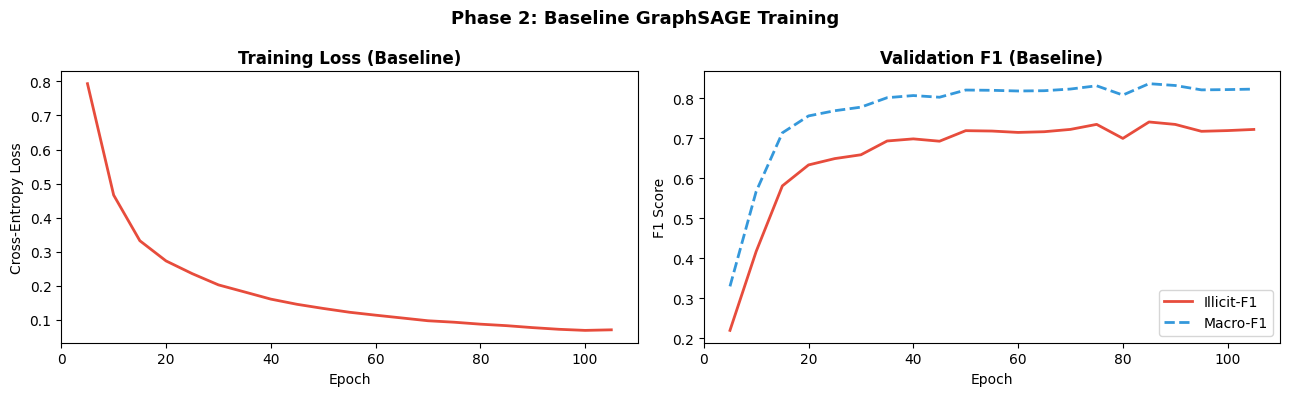

In [15]:
# ── Baseline training curve plot ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x_axis = range(5, len(baseline_history['train_loss']) * 5 + 1, 5)

axes[0].plot(list(x_axis)[:len(baseline_history['train_loss'])],
             baseline_history['train_loss'], color='#e74c3c', linewidth=2)
axes[0].set_title('Training Loss (Baseline)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')

axes[1].plot(list(x_axis)[:len(baseline_history['val_illicit_f1'])],
             baseline_history['val_illicit_f1'], color='#e74c3c', linewidth=2, label='Illicit-F1')
axes[1].plot(list(x_axis)[:len(baseline_history['val_f1'])],
             baseline_history['val_f1'], color='#3498db', linewidth=2, linestyle='--', label='Macro-F1')
axes[1].set_title('Validation F1 (Baseline)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1 Score')
axes[1].legend()

plt.suptitle('Phase 2: Baseline GraphSAGE Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'baseline_training_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 🤖 Phase 3 — TempoStruct-GAN

### 3.1 Model Architecture

Three sub-modules:
1. **Generator** — `[noise; temporal_conditioning] → synthetic_features`
2. **Edge Predictor** — `score(synth_node, candidate) → Gumbel-softmax edges`
3. **Discriminator** — Head A (node realism) + Head B (structural realism via mini-SAGE)


In [25]:
# ── Sinusoidal Positional Encoding for timestep ───────────────────────────────
class SinusoidalPE(nn.Module):
    """Maps integer timestep → d_model-dim sinusoidal embedding (Transformer-style)."""
    def __init__(self, d_model=64, T_max=49):
        super().__init__()
        pe = torch.zeros(T_max + 1, d_model)
        pos = torch.arange(0, T_max + 1).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        self.register_buffer('pe', pe)
    def forward(self, t):
        return self.pe[t]


# ── Generator ─────────────────────────────────────────────────────────────────
class TemporalGenerator(nn.Module):
    """
    Conditioning: [real_feat | neighbourhood_mean | sinusoidal_PE(t)]
    Input       : [noise | conditioning_embed]
    Output      : synthetic node features [B, feat_dim]
    """
    def __init__(self, feat_dim=166, noise_dim=64, pe_dim=64, hidden=512):
        super().__init__()
        self.feat_dim  = feat_dim
        self.noise_dim = noise_dim
        self.pe = SinusoidalPE(pe_dim)
        # Condition encoder
        cond_in = feat_dim + feat_dim + pe_dim
        self.cond_enc = nn.Sequential(
            nn.Linear(cond_in, hidden), nn.LayerNorm(hidden), nn.LeakyReLU(0.2)
        )
        # Generator MLP
        self.net = nn.Sequential(
            nn.Linear(noise_dim + hidden, hidden), nn.BatchNorm1d(hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden),             nn.BatchNorm1d(hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden // 2),        nn.BatchNorm1d(hidden // 2), nn.LeakyReLU(0.2),
            nn.Linear(hidden // 2, feat_dim),      nn.Tanh()
        )

    def forward(self, z, real_feats, neigh_feats, ts):
        """ts: [B] integer timesteps."""
        pe_emb = self.pe(ts)                                     # [B, pe_dim]
        cond   = self.cond_enc(torch.cat([real_feats, neigh_feats, pe_emb], dim=-1))
        return self.net(torch.cat([z, cond], dim=-1))


# ── Edge Predictor ────────────────────────────────────────────────────────────
class EdgePredictor(nn.Module):
    """
    Scores candidate nodes for connection to a synthetic node.
    Uses Gumbel-softmax (differentiable) during training; top-k at inference.
    Temporal constraint: candidates with t > t_synth get -inf logit.
    """
    def __init__(self, feat_dim=166, hidden=256, k=5, tau=1.0):
        super().__init__()
        self.k   = k
        self.tau = tau
        self.scorer = nn.Sequential(
            nn.Linear(feat_dim * 2 + 1, hidden), nn.LayerNorm(hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden // 2),       nn.LeakyReLU(0.2),
            nn.Linear(hidden // 2, 1)
        )

    def forward(self, synth_feats, cand_feats, synth_ts, cand_ts):
        """
        Returns (soft_weights [B,C], hard_weights [B,C]).
        synth_feats: [B, F], cand_feats: [C, F], synth_ts: [B], cand_ts: [C]
        """
        B, C = synth_feats.size(0), cand_feats.size(0)

        # Expand for pairwise scoring
        s_exp = synth_feats.unsqueeze(1).expand(B, C, -1)   # [B, C, F]
        c_exp = cand_feats.unsqueeze(0).expand(B, C, -1)    # [B, C, F]
        dt    = (synth_ts.unsqueeze(1) - cand_ts.unsqueeze(0)).float().abs().unsqueeze(-1)  # [B, C, 1]

        inp    = torch.cat([s_exp, c_exp, dt], dim=-1)      # [B, C, 2F+1]
        logits = self.scorer(inp).squeeze(-1)                # [B, C]

        # Temporal mask: candidates with t > t_synth → -inf
        future_mask = cand_ts.unsqueeze(0) > synth_ts.unsqueeze(1)  # [B, C]
        logits = logits.masked_fill(future_mask, -1e9)


        # Gumbel-softmax
        gumbel = -torch.log(-torch.log(torch.rand_like(logits).clamp(1e-20)) + 1e-20)
        perturbed = (logits + gumbel) / max(self.tau, 1e-3)
        soft = F.softmax(perturbed, dim=-1)

        # Top-k hard selection with straight-through
        k_eff = min(self.k, (~future_mask[0]).sum().item())
        k_eff = max(k_eff, 1)
        _, topk_idx = perturbed.topk(k_eff, dim=-1)
        hard = torch.zeros_like(soft)
        hard.scatter_(1, topk_idx, 1.0)
        hard_st = (hard - soft).detach() + soft  # straight-through

        return soft, hard_st

    def anneal(self, rate=0.01, tau_min=0.1):
        self.tau = max(tau_min, self.tau * (1 - rate))


# ── Dual-Head Discriminator ───────────────────────────────────────────────────
class NodeDiscriminator(nn.Module):
    """Head A — node-level realism (spectral norm for stability)."""
    def __init__(self, feat_dim=166, hidden=256):
        super().__init__()
        SN = nn.utils.spectral_norm
        self.net = nn.Sequential(
            SN(nn.Linear(feat_dim, hidden)), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            SN(nn.Linear(hidden, hidden // 2)), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            SN(nn.Linear(hidden // 2, 1))
        )
    def forward(self, x): return self.net(x)


class StructuralDiscriminator(nn.Module):
    """
    Head B — adversarially-learned structural realism (Novelty Claim #2).
    Encodes the local subgraph (center node + neighbours) via 2-layer SAGE,
    then classifies using graph embedding + hand-crafted structural stats.

    This head is TRAINED adversarially — its weights update via backprop,
    actively reshaping what the generator learns to produce.
    (Unlike THG-OAFN's fixed rule-based post-hoc filter.)
    """
    def __init__(self, feat_dim=166, struct_dim=4, hidden=128):
        super().__init__()
        self.conv1 = make_conv(feat_dim, hidden)
        self.conv2 = make_conv(hidden, hidden // 2)
        SN = nn.utils.spectral_norm
        self.clf = nn.Sequential(
            SN(nn.Linear(hidden // 2 + struct_dim, hidden)), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            SN(nn.Linear(hidden, 1))
        )

    def forward(self, subgraph_x, subgraph_ei, struct_stats):
        h = F.leaky_relu(self.conv1(subgraph_x, subgraph_ei), 0.2)
        h = F.leaky_relu(self.conv2(h, subgraph_ei), 0.2)
        emb = h[0]  # center node embedding
        return self.clf(torch.cat([emb, struct_stats], dim=-1))


print('✅ GAN architecture defined (Generator, EdgePredictor, 2-Head Discriminator)')

✅ GAN architecture defined (Generator, EdgePredictor, 2-Head Discriminator)


In [26]:
# ── Instantiate GAN components ───────────────────────────────────────────────
NOISE_DIM  = 64
PE_DIM     = 64
GEN_HIDDEN = 512
EDGE_K     = 5     # edges per synthetic node

generator    = TemporalGenerator(FEAT_DIM, NOISE_DIM, PE_DIM, GEN_HIDDEN).to(DEVICE)
edge_pred    = EdgePredictor(FEAT_DIM, hidden=256, k=EDGE_K, tau=1.0).to(DEVICE)
disc_node    = NodeDiscriminator(FEAT_DIM, 256).to(DEVICE)
disc_struct  = StructuralDiscriminator(FEAT_DIM, struct_dim=4, hidden=128).to(DEVICE)

# Parameter counts
def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f'Generator    params: {count_params(generator):,}')
print(f'EdgePredictor params: {count_params(edge_pred):,}')
print(f'Disc Node    params: {count_params(disc_node):,}')
print(f'Disc Struct  params: {count_params(disc_struct):,}')

Generator    params: 938,918
EdgePredictor params: 119,041
Disc Node    params: 75,777
Disc Struct  params: 68,033


In [27]:
# ── Loss functions ────────────────────────────────────────────────────────────
def adv_loss_d(real_logits, fake_logits, smoothing=0.1):
    """Discriminator BCE loss with one-sided label smoothing."""
    real_target = torch.full_like(real_logits, 1.0 - smoothing)
    fake_target = torch.zeros_like(fake_logits)
    return 0.5 * (
        F.binary_cross_entropy_with_logits(real_logits, real_target) +
        F.binary_cross_entropy_with_logits(fake_logits, fake_target)
    )

def adv_loss_g(fake_logits):
    """Non-saturating generator loss (wants D to output 1)."""
    return F.binary_cross_entropy_with_logits(fake_logits, torch.ones_like(fake_logits))

def temporal_penalty(soft_weights, synth_ts, cand_ts):
    """Penalise weights assigned to future-timestep candidates."""
    future = (cand_ts.unsqueeze(0) > synth_ts.unsqueeze(1)).float()  # [B, C]
    return (soft_weights * future).sum() / (soft_weights.shape[0] * soft_weights.shape[1])

def feature_matching(real_f, fake_f):
    """First-order feature statistics matching."""
    return F.mse_loss(fake_f.mean(0), real_f.mean(0))

print('✅ Loss functions defined')

✅ Loss functions defined


In [28]:
# ── Helper: build local subgraph for structural discriminator ─────────────────
def build_subgraph(center_feat, center_struct, cand_feats, hard_weights):
    """
    Given a synthetic center node and its hard-selected neighbours,
    build a tiny subgraph tensor for Head B.

    center_feat   : [feat_dim]  — synthetic node features
    center_struct : [4]         — structural stats of center node (estimated)
    cand_feats    : [C, feat_dim] — all candidates
    hard_weights  : [C]         — binary, 1 = selected neighbour

    Returns:
        sub_x  : [1 + k, feat_dim]  (center node first)
        sub_ei : [2, edges]         (star graph: center ↔ all selected neighbours)
        struct : [4]                (center node structural stats)
    """
    selected_idx = hard_weights.nonzero(as_tuple=True)[0]  # [k]
    k = selected_idx.size(0)
    if k == 0:
        # Degenerate case: no neighbours selected — return trivial self-loop
        sub_x  = center_feat.unsqueeze(0)  # [1, F]
        sub_ei = torch.zeros(2, 1, dtype=torch.long, device=center_feat.device)
        return sub_x, sub_ei, center_struct

    neigh_feats = cand_feats[selected_idx]  # [k, F]
    # Stack: index 0 = center, indices 1..k = neighbours
    sub_x = torch.cat([center_feat.unsqueeze(0), neigh_feats], dim=0)  # [1+k, F]

    # Star-graph edges: center → each neighbour (both directions for undirected SAGE)
    src = torch.cat([torch.zeros(k, dtype=torch.long, device=center_feat.device),
                     torch.arange(1, k + 1, dtype=torch.long, device=center_feat.device)])
    dst = torch.cat([torch.arange(1, k + 1, dtype=torch.long, device=center_feat.device),
                     torch.zeros(k, dtype=torch.long, device=center_feat.device)])
    sub_ei = torch.stack([src, dst], dim=0)  # [2, 2k]

    return sub_x, sub_ei, center_struct


def estimate_struct_stats(hard_weights, real_struct_stats_batch):
    """
    For synthetic nodes, estimate structural stats:
      degree = hard_weights.sum() (number of selected edges)
      clustering = 0 (can't compute without real neighbourhood edges)
      homophily = fraction of selected neighbours that are illicit
                 (approximated as 1.0 since we only connect to illicit-region nodes)
      ego_density = 0 (approximated)

    For real nodes, use their pre-computed structural features.
    """
    B = hard_weights.shape[0]
    stats = torch.zeros(B, 4, device=hard_weights.device)
    stats[:, 0] = hard_weights.sum(dim=-1).float()  # degree
    stats[:, 1] = 0.0    # clustering (unknown for synthetic)
    stats[:, 2] = 1.0    # homophily (assume fraud cluster context)
    stats[:, 3] = 0.0    # ego_density (unknown)
    return stats

print('✅ Subgraph helper defined')

✅ Subgraph helper defined


In [21]:
# ── GAN Training Configuration ───────────────────────────────────────────────
GAN_EPOCHS    = 300
GAN_BATCH     = 32    # number of real illicit nodes per GAN step
CAND_POOL     = 512   # candidate pool size for edge predictor
D_LR          = 1e-4
G_LR          = 5e-5
LAMBDA_TEMP   = 2.0   # temporal violation penalty weight
LAMBDA_FM     = 0.1   # feature matching weight
D_STEPS       = 2     # discriminator updates per generator update
STRUCT_EVAL_EVERY = 30  # compute structural stats every N epochs

# Optimisers
opt_D = Adam(list(disc_node.parameters()) + list(disc_struct.parameters()), lr=D_LR, betas=(0.5, 0.999))
opt_G = Adam(list(generator.parameters()) + list(edge_pred.parameters()),  lr=G_LR, betas=(0.5, 0.999))

# Illicit node indices in training set (conditioning source)
train_illicit_idx = ((labels == 1) & train_mask).nonzero(as_tuple=True)[0].to(DEVICE)
print(f'Training illicit nodes available for conditioning: {len(train_illicit_idx):,}')

# Move global tensors to device
X_dev       = X.to(DEVICE)
ei_dev      = edge_index.to(DEVICE)
ts_dev      = timestep.to(DEVICE)
sf_dev      = struct_feat.to(DEVICE)
labels_dev  = labels.to(DEVICE)

print(f'GAN training config: {GAN_EPOCHS} epochs, batch={GAN_BATCH}, D_steps={D_STEPS}')

Training illicit nodes available for conditioning: 2,871
GAN training config: 300 epochs, batch=32, D_steps=2


In [29]:
# ── GAN Training Loop ────────────────────────────────────────────────────────
gan_history = {
    'loss_D': [], 'loss_G': [], 'loss_D_node': [], 'loss_D_struct': [],
    'loss_G_node': [], 'loss_G_struct': [], 'temporal_violation': [], 'epoch': []
}
structural_snapshots = {}  # epoch → {real_degrees, fake_degrees, real_clust, fake_clust}

print(f'Starting GAN training ({GAN_EPOCHS} epochs)...')
print('This will take a while. Progress every 10 epochs.\n')
gan_start = time.time()

for epoch in range(1, GAN_EPOCHS + 1):
    generator.train(); edge_pred.train()
    disc_node.train(); disc_struct.train()

    # ─── Sample real illicit conditioning nodes (batch) ───
    rand_idx     = torch.randperm(len(train_illicit_idx))[:GAN_BATCH]
    cond_nodes   = train_illicit_idx[rand_idx]             # [B]
    real_feats   = X_dev[cond_nodes]                       # [B, F]
    real_ts      = ts_dev[cond_nodes]                      # [B]
    real_structs = sf_dev[cond_nodes]                      # [B, 4]

    # Neighbourhood mean (simple 1-hop from edge index)
    src, dst = ei_dev
    neigh_means = []
    for node in cond_nodes:
        nbr_mask = (src == node) | (dst == node)
        nbr_idx  = torch.cat([dst[src == node], src[dst == node]]).unique()
        if len(nbr_idx) > 0:
            neigh_means.append(X_dev[nbr_idx].mean(0))
        else:
            neigh_means.append(X_dev[node])
    neigh_feats = torch.stack(neigh_means, dim=0)  # [B, F]

    # ─── Candidate pool for edge predictor ───
    # Sample from training illicit nodes within same-ish timestep range
    cand_pool_idx = train_illicit_idx[torch.randperm(len(train_illicit_idx))[:CAND_POOL]]
    cand_feats    = X_dev[cand_pool_idx]            # [C, F]
    cand_ts       = ts_dev[cand_pool_idx]           # [C]

    # ─── Generate fake nodes ───
    z = torch.randn(GAN_BATCH, NOISE_DIM, device=DEVICE)
    fake_feats = generator(z, real_feats, neigh_feats, real_ts)   # [B, F]

    # ─── Edge prediction ───
    soft_w, hard_w = edge_pred(fake_feats, cand_feats, real_ts, cand_ts)  # [B, C] each

    # ─── Build subgraphs for Head B ───
    fake_struct_stats = estimate_struct_stats(hard_w, real_structs)

    # ─── Train Discriminator (D_STEPS times) ─────────────────────────────────
    for d_step in range(D_STEPS):
        opt_D.zero_grad()

        # Head A: node-level
        real_node_logits = disc_node(real_feats)                # [B, 1]
        fake_node_logits = disc_node(fake_feats.detach())       # [B, 1]
        loss_D_node = adv_loss_d(real_node_logits, fake_node_logits)

        # Head B: structural — evaluate on individual samples
        d_struct_real_logits, d_struct_fake_logits = [], []
        for i in range(GAN_BATCH):
            sub_x_r, sub_ei_r, _ = build_subgraph(
                real_feats[i], real_structs[i], cand_feats, hard_w[i].detach()
            )
            logit_r = disc_struct(sub_x_r, sub_ei_r, real_structs[i])
            d_struct_real_logits.append(logit_r)

            sub_x_f, sub_ei_f, _ = build_subgraph(
                fake_feats[i].detach(), fake_struct_stats[i], cand_feats, hard_w[i].detach()
            )
            logit_f = disc_struct(sub_x_f, sub_ei_f, fake_struct_stats[i])
            d_struct_fake_logits.append(logit_f)

        real_struct_logits = torch.stack(d_struct_real_logits).squeeze(-1)
        fake_struct_logits = torch.stack(d_struct_fake_logits).squeeze(-1)
        loss_D_struct = adv_loss_d(real_struct_logits, fake_struct_logits)

        loss_D = loss_D_node + loss_D_struct
        loss_D.backward(retain_graph=True)

        torch.nn.utils.clip_grad_norm_(
            list(disc_node.parameters()) + list(disc_struct.parameters()), 1.0
        )
        opt_D.step()

    # ─── Train Generator + Edge Predictor ────────────────────────────────────
    opt_G.zero_grad()

    # Re-generate with gradients
    z2 = torch.randn(GAN_BATCH, NOISE_DIM, device=DEVICE)
    fake_feats2 = generator(z2, real_feats, neigh_feats, real_ts)
    soft_w2, hard_w2 = edge_pred(fake_feats2, cand_feats, real_ts, cand_ts)
    fake_struct_stats2 = estimate_struct_stats(hard_w2, real_structs)

    # Head A generator loss
    g_node_logits = disc_node(fake_feats2)
    loss_G_node = adv_loss_g(g_node_logits)

    # Head B generator loss
    g_struct_logits = []
    for i in range(GAN_BATCH):
        sub_x_f, sub_ei_f, _ = build_subgraph(
            fake_feats2[i], fake_struct_stats2[i], cand_feats, hard_w2[i]
        )
        logit_f = disc_struct(sub_x_f, sub_ei_f, fake_struct_stats[i].detach())

        g_struct_logits.append(logit_f)
    g_struct_logits = torch.stack(g_struct_logits).squeeze(-1)
    loss_G_struct = adv_loss_g(g_struct_logits)

    # Temporal violation penalty
    loss_temp = temporal_penalty(soft_w2, real_ts, cand_ts)

    # Feature matching
    loss_fm = feature_matching(real_feats, fake_feats2)

    loss_G = loss_G_node + loss_G_struct + LAMBDA_TEMP * loss_temp + LAMBDA_FM * loss_fm
    loss_G.backward()
    torch.nn.utils.clip_grad_norm_(
        list(generator.parameters()) + list(edge_pred.parameters()), 1.0
    )
    opt_G.step()

    # ─── Anneal Gumbel temperature ───
    edge_pred.anneal(rate=0.003, tau_min=0.1)

    # ─── Logging ─────────────────────────────────────────────────────────────
    temp_viol = loss_temp.item()
    gan_history['loss_D'].append(loss_D.item())
    gan_history['loss_G'].append(loss_G.item())
    gan_history['loss_D_node'].append(loss_D_node.item())
    gan_history['loss_D_struct'].append(loss_D_struct.item())
    gan_history['loss_G_node'].append(loss_G_node.item())
    gan_history['loss_G_struct'].append(loss_G_struct.item())
    gan_history['temporal_violation'].append(temp_viol)
    gan_history['epoch'].append(epoch)

    if epoch % 10 == 0:
        elapsed = time.time() - gan_start
        print(f'  Epoch {epoch:3d}/{GAN_EPOCHS} | '
              f'D={loss_D.item():.4f} G={loss_G.item():.4f} '
              f'TempViol={temp_viol:.4f} | tau={edge_pred.tau:.3f} | '
              f'Elapsed: {elapsed:.0f}s')

    # ─── Structural stats snapshot ────────────────────────────────────────────
    if epoch % STRUCT_EVAL_EVERY == 0 or epoch == 1:
        with torch.no_grad():
            z_eval = torch.randn(100, NOISE_DIM, device=DEVICE)
            eval_idx = train_illicit_idx[torch.randperm(len(train_illicit_idx))[:100]]
            rf_eval  = X_dev[eval_idx]
            ts_eval  = ts_dev[eval_idx]
            nm_eval  = torch.stack([
                X_dev[torch.cat([dst[src == n], src[dst == n]]).unique()].mean(0)
                if len(torch.cat([dst[src == n], src[dst == n]]).unique()) > 0
                else X_dev[n]
                for n in eval_idx
            ], dim=0)
            fake_eval = generator(z_eval, rf_eval, nm_eval, ts_eval)
            sw_eval, hw_eval = edge_pred(fake_eval,
                                         cand_feats,
                                         ts_eval,
                                         cand_ts)
            fake_degrees = hw_eval.sum(dim=-1).cpu().numpy()
            real_degrees_snap = sf_dev[eval_idx, 0].cpu().numpy()
            real_clust_snap   = sf_dev[eval_idx, 1].cpu().numpy()

        structural_snapshots[epoch] = {
            'real_degrees':    real_degrees_snap,
            'fake_degrees':    fake_degrees,
            'real_clustering': real_clust_snap,
        }

print(f'\n✅ GAN training complete in {time.time()-gan_start:.0f}s')

Starting GAN training (300 epochs)...
This will take a while. Progress every 10 epochs.

  Epoch  10/300 | D=1.3805 G=1.3515 TempViol=0.0000 | tau=0.970 | Elapsed: 11s
  Epoch  20/300 | D=1.4003 G=1.3539 TempViol=0.0000 | tau=0.942 | Elapsed: 20s
  Epoch  30/300 | D=1.3912 G=1.3338 TempViol=0.0000 | tau=0.914 | Elapsed: 30s
  Epoch  40/300 | D=1.3932 G=1.3583 TempViol=0.0000 | tau=0.887 | Elapsed: 40s
  Epoch  50/300 | D=1.3829 G=1.3601 TempViol=0.0000 | tau=0.861 | Elapsed: 51s
  Epoch  60/300 | D=1.3891 G=1.3189 TempViol=0.0000 | tau=0.835 | Elapsed: 61s
  Epoch  70/300 | D=1.3934 G=1.3410 TempViol=0.0000 | tau=0.810 | Elapsed: 71s
  Epoch  80/300 | D=1.3880 G=1.3318 TempViol=0.0000 | tau=0.786 | Elapsed: 81s
  Epoch  90/300 | D=1.3874 G=1.3754 TempViol=0.0000 | tau=0.763 | Elapsed: 91s
  Epoch 100/300 | D=1.3835 G=1.3344 TempViol=0.0000 | tau=0.740 | Elapsed: 101s
  Epoch 110/300 | D=1.3894 G=1.3386 TempViol=0.0000 | tau=0.719 | Elapsed: 111s
  Epoch 120/300 | D=1.3700 G=1.3493 Temp

In [30]:
# ── Save GAN checkpoints ─────────────────────────────────────────────────────
models_save_dir = MODELS_DIR
os.makedirs(models_save_dir, exist_ok=True)

torch.save(generator.state_dict(),   os.path.join(models_save_dir, 'graphguard_generator.pt'))
torch.save(edge_pred.state_dict(),   os.path.join(models_save_dir, 'graphguard_edge_predictor.pt'))
torch.save(disc_node.state_dict(),   os.path.join(models_save_dir, 'graphguard_disc_node.pt'))
torch.save(disc_struct.state_dict(), os.path.join(models_save_dir, 'graphguard_disc_struct.pt'))

# Save training history
import json
with open(os.path.join(RESULTS_DIR, 'gan_training_history.json'), 'w') as f:
    json.dump(gan_history, f)

print('✅ GAN checkpoints and history saved')

✅ GAN checkpoints and history saved


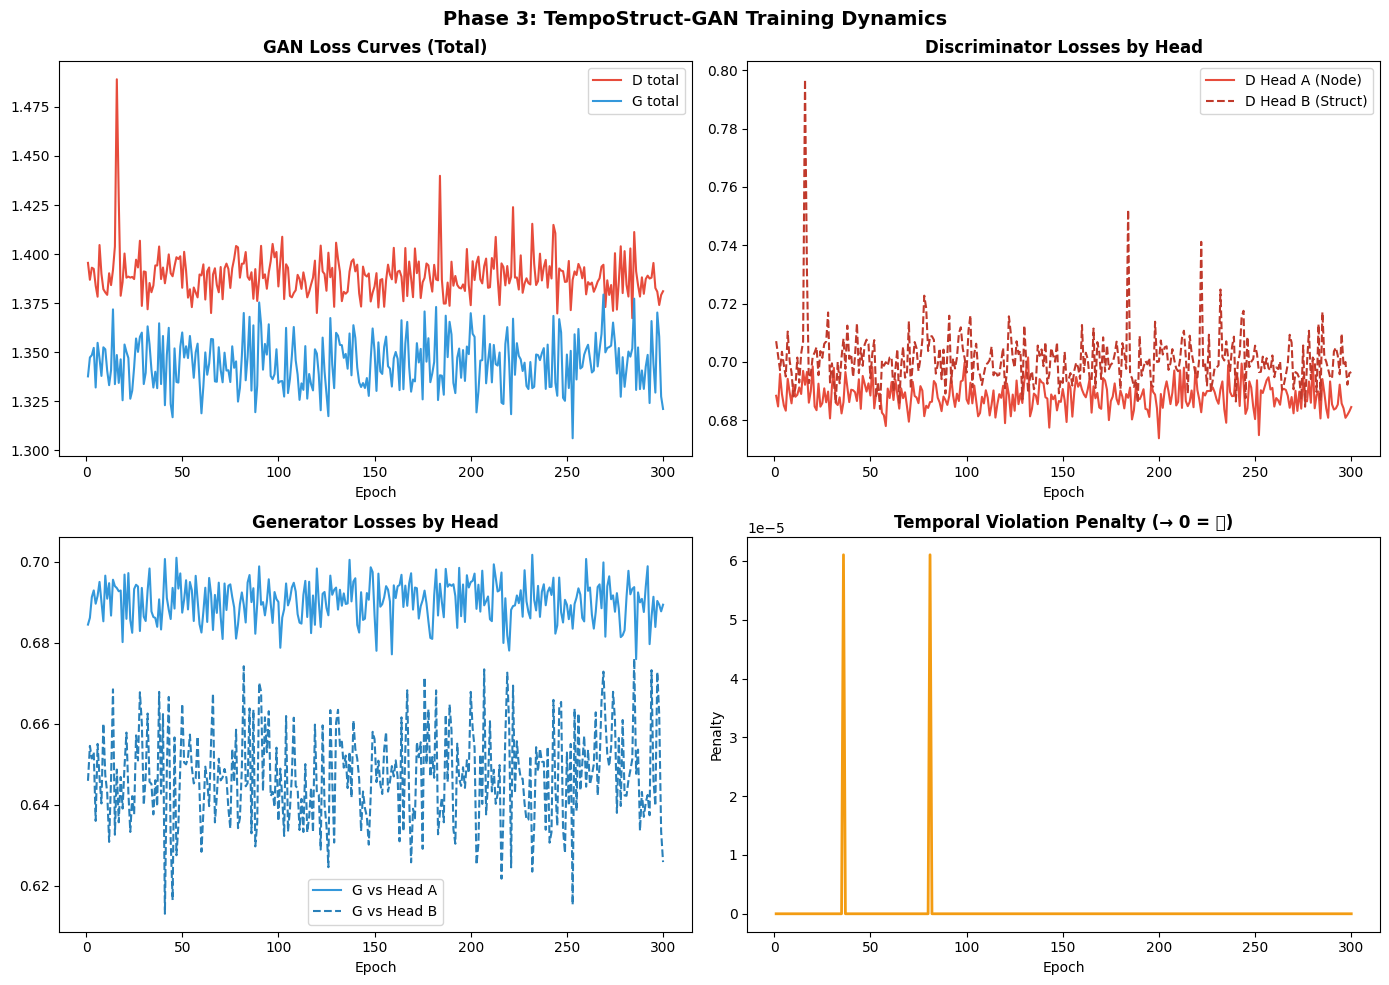

✅ Saved: gan_loss_curves.png


In [31]:
# ── GAN loss curves plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
epochs = gan_history['epoch']

axes[0, 0].plot(epochs, gan_history['loss_D'], color='#e74c3c', linewidth=1.5, label='D total')
axes[0, 0].plot(epochs, gan_history['loss_G'], color='#3498db', linewidth=1.5, label='G total')
axes[0, 0].set_title('GAN Loss Curves (Total)', fontweight='bold')
axes[0, 0].legend(); axes[0, 0].set_xlabel('Epoch')

axes[0, 1].plot(epochs, gan_history['loss_D_node'],   color='#e74c3c', linewidth=1.5, label='D Head A (Node)')
axes[0, 1].plot(epochs, gan_history['loss_D_struct'], color='#c0392b', linewidth=1.5, linestyle='--', label='D Head B (Struct)')
axes[0, 1].set_title('Discriminator Losses by Head', fontweight='bold')
axes[0, 1].legend(); axes[0, 1].set_xlabel('Epoch')

axes[1, 0].plot(epochs, gan_history['loss_G_node'],   color='#3498db', linewidth=1.5, label='G vs Head A')
axes[1, 0].plot(epochs, gan_history['loss_G_struct'], color='#2980b9', linewidth=1.5, linestyle='--', label='G vs Head B')
axes[1, 0].set_title('Generator Losses by Head', fontweight='bold')
axes[1, 0].legend(); axes[1, 0].set_xlabel('Epoch')

axes[1, 1].plot(epochs, gan_history['temporal_violation'], color='#f39c12', linewidth=2)
axes[1, 1].set_title('Temporal Violation Penalty (→ 0 = ✅)', fontweight='bold')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Penalty')

plt.suptitle('Phase 3: TempoStruct-GAN Training Dynamics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'gan_loss_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: gan_loss_curves.png')

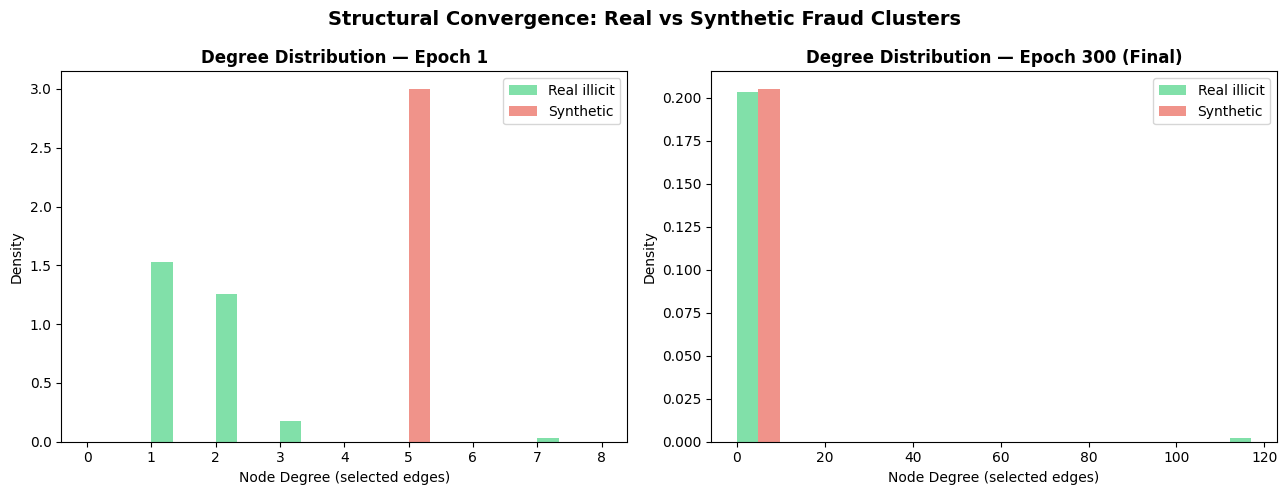

✅ Saved: gan_structural_convergence.png  ← Show this at Review-2!


In [33]:
# ── Structural convergence plot (Review-2 slide) ─────────────────────────────
# Compare real vs fake degree distributions at epoch 1 vs final epoch
import numpy as np
snap_epochs = sorted(structural_snapshots.keys())
first_epoch  = snap_epochs[0]
last_epoch   = snap_epochs[-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, ep, title_tag in [(axes[0], first_epoch, f'Epoch {first_epoch}'),
                           (axes[1], last_epoch,  f'Epoch {last_epoch} (Final)')]:
    snap = structural_snapshots[ep]
    max_deg = max(snap['real_degrees'].max(), snap['fake_degrees'].max()) + 1
    bins = np.linspace(0, max_deg, 25)

    ax.hist(snap['real_degrees'], bins=bins, alpha=0.6, color='#2ecc71',
            label='Real illicit', density=True)
    ax.hist(snap['fake_degrees'], bins=bins, alpha=0.6, color='#e74c3c',
            label='Synthetic',    density=True)
    ax.set_title(f'Degree Distribution — {title_tag}', fontweight='bold')
    ax.set_xlabel('Node Degree (selected edges)')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Structural Convergence: Real vs Synthetic Fraud Clusters',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'gan_structural_convergence.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: gan_structural_convergence.png  ← Show this at Review-2!')

---
## ⚖️ Phase 4 — Augmented Classifier Training

Generate synthetic illicit nodes → merge into training graph → retrain GraphSAGE.  
Sweep augmentation ratios: **10%, 20%, 30%** of illicit class size.

In [36]:
# ── Generate synthetic nodes ─────────────────────────────────────────────────
AUG_RATIOS = [0.10, 0.20, 0.30]  # fraction of current illicit count to generate

augmented_results = {}

generator.eval(); edge_pred.eval()

for aug_ratio in AUG_RATIOS:
    N_SYN = int(n_illicit_train * aug_ratio)
    print(f'\n── Augmentation ratio: {int(aug_ratio*100)}%  → generating {N_SYN} synthetic nodes ──')

    # Sample conditioning nodes
    cond_idx_aug = train_illicit_idx[torch.randperm(len(train_illicit_idx))[:N_SYN]]
    rf_aug = X_dev[cond_idx_aug]
    ts_aug = ts_dev[cond_idx_aug]

    nm_aug = []
    for node in cond_idx_aug:
        nb = torch.cat([dst[src == node], src[dst == node]]).unique()
        nm_aug.append(X_dev[nb].mean(0) if len(nb) > 0 else X_dev[node])
    nm_aug = torch.stack(nm_aug)

    with torch.no_grad():
        z_aug  = torch.randn(N_SYN, NOISE_DIM, device=DEVICE)
        syn_feats = generator(z_aug, rf_aug, nm_aug, ts_aug)   # [N_SYN, F]

        # Edge prediction for synthetic nodes
        cand_aug_idx = train_illicit_idx[torch.randperm(len(train_illicit_idx))[:min(CAND_POOL, len(train_illicit_idx))]]
        cand_feats_aug = X_dev[cand_aug_idx]
        cand_ts_aug    = ts_dev[cand_aug_idx]

        _, hw_aug = edge_pred(syn_feats, cand_feats_aug, ts_aug, cand_ts_aug)

    # ── Merge into training graph ───────────────────────────────────────────
    # Synthetic nodes get IDs starting at N
    syn_node_ids   = torch.arange(N, N + N_SYN, device=DEVICE)
    syn_labels     = torch.ones(N_SYN, dtype=torch.long, device=DEVICE)  # all illicit
    syn_train_mask = torch.ones(N_SYN, dtype=torch.bool, device=DEVICE)

    # Add synthetic edges (top-1 per synthetic node for simplicity here)
    syn_srcs, syn_dsts = [], []
    for i in range(N_SYN):
        selected = hw_aug[i].nonzero(as_tuple=True)[0]
        if len(selected) == 0:
            continue
        for s in selected:
            real_target = cand_aug_idx[s].item()
            syn_srcs.append(N + i)
            syn_dsts.append(real_target)
            syn_srcs.append(real_target)
            syn_dsts.append(N + i)

    if syn_srcs:
        syn_ei = torch.tensor([syn_srcs, syn_dsts], dtype=torch.long, device=DEVICE)
        aug_edge_index = torch.cat([ei_dev, syn_ei], dim=1)
    else:
        aug_edge_index = ei_dev

    # Augmented feature matrix
    aug_X      = torch.cat([X_dev, syn_feats], dim=0)
    aug_labels = torch.cat([labels_dev, syn_labels])

    # Updated masks
    aug_train_lbl = torch.cat([train_lbl.to(DEVICE), syn_train_mask])
    aug_val_lbl   = torch.cat([val_lbl.to(DEVICE),   torch.zeros(N_SYN, dtype=torch.bool, device=DEVICE)])
    aug_test_lbl  = torch.cat([test_lbl.to(DEVICE),  torch.zeros(N_SYN, dtype=torch.bool, device=DEVICE)])

    print(f'  Augmented graph: {aug_X.shape[0]:,} nodes, {aug_edge_index.shape[1]:,} edges')
    aug_illicit = (aug_labels[aug_train_lbl] == 1).sum().item()
    aug_licit   = (aug_labels[aug_train_lbl] == 0).sum().item()
    print(f'  Train illicit: {aug_illicit:,}, licit: {aug_licit:,}  (ratio 1:{aug_licit//aug_illicit})')

    # ── Train augmented GraphSAGE ───────────────────────────────────────────
    aug_class_counts = torch.tensor([aug_licit, aug_illicit], dtype=torch.float)
    aug_weights = (1.0 / aug_class_counts).to(DEVICE)
    aug_weights = aug_weights / aug_weights.sum()

    aug_model = GraphSAGEClassifier(in_c=FEAT_DIM).to(DEVICE)
    opt_aug   = Adam(aug_model.parameters(), lr=1e-3, weight_decay=5e-4)

    best_aug_f1, best_aug_state, aug_pat = 0.0, None, 0

    for ep in range(1, BASELINE_EPOCHS + 1):
        aug_model.train()
        opt_aug.zero_grad()
        logits_aug = aug_model(aug_X, aug_edge_index)

        train_idx_aug = aug_train_lbl.nonzero(as_tuple=True)[0]
        loss_aug = F.cross_entropy(logits_aug[train_idx_aug],
                                   aug_labels[train_idx_aug], weight=aug_weights)
        loss_aug.backward()
        torch.nn.utils.clip_grad_norm_(aug_model.parameters(), 1.0)
        opt_aug.step()

        if ep % 5 == 0:
            aug_model.eval()
            with torch.no_grad():
                val_logits_aug = logits_aug[aug_val_lbl]
                val_labels_aug = aug_labels[aug_val_lbl]
                val_preds_aug  = val_logits_aug.argmax(-1)

            y_t = val_labels_aug.cpu().numpy()
            y_p = val_preds_aug.cpu().numpy()
            known_v = y_t != -1
            if known_v.sum() > 0:
                aug_f1 = f1_score(y_t[known_v], y_p[known_v], pos_label=1, zero_division=0)
                if aug_f1 > best_aug_f1:
                    best_aug_f1    = aug_f1
                    best_aug_state = copy.deepcopy(aug_model.state_dict())
                    aug_pat = 0
                else:
                    aug_pat += 1
            if aug_pat >= BASELINE_PATIENCE // 5:
                break

    # ── Test evaluation ─────────────────────────────────────────────────────
    aug_model.load_state_dict(best_aug_state)
    aug_model.eval()
    with torch.no_grad():
        test_logits_aug = aug_model(aug_X, aug_edge_index)[aug_test_lbl]
        test_labels_aug = aug_labels[aug_test_lbl]
        test_preds_aug  = test_logits_aug.argmax(-1)
        test_probs_aug  = F.softmax(test_logits_aug, -1)[:, 1]

    y_t = test_labels_aug.cpu().numpy()
    y_p = test_preds_aug.cpu().numpy()
    y_pr = test_probs_aug.cpu().numpy()
    kn = y_t != -1

    res = {
        'aug_ratio': aug_ratio,
        'n_synthetic': N_SYN,
        'illicit_f1':        f1_score(y_t[kn], y_p[kn], pos_label=1, zero_division=0),
        'illicit_recall':    recall_score(y_t[kn], y_p[kn], pos_label=1, zero_division=0),
        'illicit_precision': precision_score(y_t[kn], y_p[kn], pos_label=1, zero_division=0),
        'auc_roc':           roc_auc_score(y_t[kn], y_pr[kn]),
        'auc_pr':            average_precision_score(y_t[kn], y_pr[kn]),
        'macro_f1':          f1_score(y_t[kn], y_p[kn], average='macro', zero_division=0),
    }
    augmented_results[aug_ratio] = res

    # Save model
    torch.save(best_aug_state,
               os.path.join(models_save_dir, f'graphguard_classifier_aug{int(aug_ratio*100)}.pt'))

    print(f'  → Illicit-F1: {res["illicit_f1"]:.4f}  '
          f'Recall: {res["illicit_recall"]:.4f}  '
          f'Precision: {res["illicit_precision"]:.4f}  '
          f'AUC-PR: {res["auc_pr"]:.4f}')

# Save best (20%) as primary model
import shutil
shutil.copy(
    os.path.join(models_save_dir, 'graphguard_classifier_aug20.pt'),
    os.path.join(models_save_dir, 'graphguard_classifier.pt')
)

print('\n✅ All augmentation ratios complete. Best model saved as graphguard_classifier.pt')


── Augmentation ratio: 10%  → generating 287 synthetic nodes ──
  Augmented graph: 204,056 nodes, 237,225 edges
  Train illicit: 3,158, licit: 23,510  (ratio 1:7)
  → Illicit-F1: 0.3627  Recall: 0.7442  Precision: 0.2398  AUC-PR: 0.5849

── Augmentation ratio: 20%  → generating 574 synthetic nodes ──
  Augmented graph: 204,343 nodes, 240,095 edges
  Train illicit: 3,445, licit: 23,510  (ratio 1:6)
  → Illicit-F1: 0.3683  Recall: 0.7378  Precision: 0.2454  AUC-PR: 0.4807

── Augmentation ratio: 30%  → generating 861 synthetic nodes ──
  Augmented graph: 204,630 nodes, 242,965 edges
  Train illicit: 3,732, licit: 23,510  (ratio 1:6)
  → Illicit-F1: 0.3652  Recall: 0.7461  Precision: 0.2418  AUC-PR: 0.4980

✅ All augmentation ratios complete. Best model saved as graphguard_classifier.pt


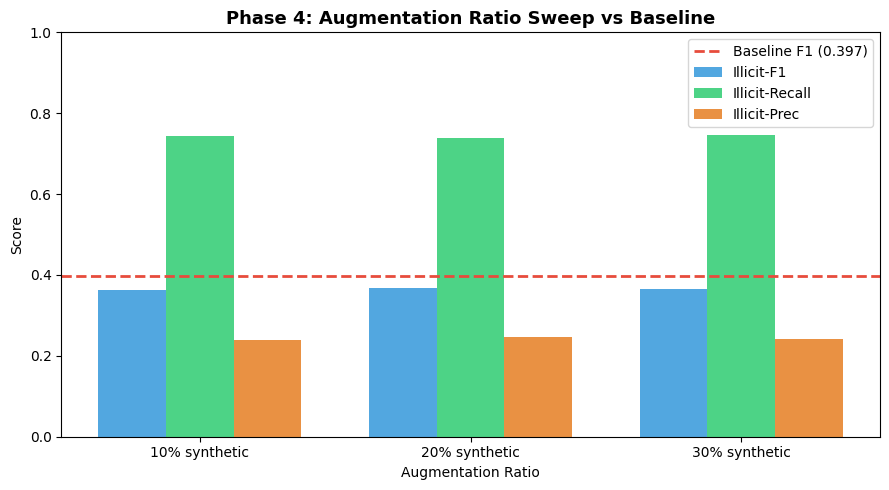

✅ Saved: augmentation_ratio_sweep.png


In [37]:
# ── Augmentation ratio sweep plot ────────────────────────────────────────────
ratios   = [int(r * 100) for r in AUG_RATIOS]
f1_vals  = [augmented_results[r]['illicit_f1']  for r in AUG_RATIOS]
rec_vals = [augmented_results[r]['illicit_recall']  for r in AUG_RATIOS]
prec_vals= [augmented_results[r]['illicit_precision'] for r in AUG_RATIOS]

baseline_f1 = baseline_results['illicit_f1']

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(ratios))
w = 0.25

ax.bar(x - w, f1_vals,   width=w, label='Illicit-F1',    color='#3498db', alpha=0.85)
ax.bar(x,     rec_vals,  width=w, label='Illicit-Recall', color='#2ecc71', alpha=0.85)
ax.bar(x + w, prec_vals, width=w, label='Illicit-Prec',   color='#e67e22', alpha=0.85)
ax.axhline(baseline_f1, color='#e74c3c', linewidth=2, linestyle='--',
           label=f'Baseline F1 ({baseline_f1:.3f})')

ax.set_xticks(x)
ax.set_xticklabels([f'{r}% synthetic' for r in ratios])
ax.set_xlabel('Augmentation Ratio')
ax.set_ylabel('Score')
ax.set_title('Phase 4: Augmentation Ratio Sweep vs Baseline', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'augmentation_ratio_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: augmentation_ratio_sweep.png')

In [38]:
# ── Phase 2+4 summary comparison ─────────────────────────────────────────────
import pandas as pd
rows = [{'Method': 'Baseline GraphSAGE (no aug)', **baseline_results}]
for ratio, res in augmented_results.items():
    rows.append({'Method': f'GraphGuard ({int(ratio*100)}% aug)', **{k: v for k, v in res.items() if k not in ['aug_ratio', 'n_synthetic']}})

summary_df = pd.DataFrame(rows).set_index('Method')
summary_df = summary_df[['illicit_f1', 'illicit_recall', 'illicit_precision', 'auc_roc', 'auc_pr', 'macro_f1']]
summary_df.columns = ['Illicit-F1', 'Recall', 'Precision', 'AUC-ROC', 'AUC-PR', 'Macro-F1']

print('\n' + '='*80)
print('PHASE 2 + 4 RESULTS COMPARISON')
print('='*80)
print(summary_df.to_string(float_format='{:.4f}'.format))

summary_df.to_csv(os.path.join(RESULTS_DIR, 'phase24_comparison.csv'))
print('\n✅ Saved: phase24_comparison.csv')


PHASE 2 + 4 RESULTS COMPARISON
                             Illicit-F1  Recall  Precision  AUC-ROC  AUC-PR  Macro-F1
Method                                                                               
Baseline GraphSAGE (no aug)      0.3970  0.7350     0.2720   0.8972  0.6471    0.6573
GraphGuard (10% aug)             0.3627  0.7442     0.2398   0.8904  0.5849    0.6324
GraphGuard (20% aug)             0.3683  0.7378     0.2454   0.8857  0.4807    0.6369
GraphGuard (30% aug)             0.3652  0.7461     0.2418   0.8871  0.4980    0.6340

✅ Saved: phase24_comparison.csv
